# Mini Google Lens

In [ ]:
#Extract the .tar file
import tarfile

tar_path = "./dataset/256_ObjectCategories.tar"
extract_path = "./dataset"

with tarfile.open(tar_path) as tar:
    tar.extractall(path=extract_path)

print("Extraction done")

In [2]:
#Check dataset structure
import os

base_path = "./dataset/256_ObjectCategories"

print("Number of classes:", len(os.listdir(base_path)))
print("Sample classes:", os.listdir(base_path)[:5])

Number of classes: 257
Sample classes: ['138.mattress', '107.hot-air-balloon', '037.chess-board', '022.buddha-101', '024.butterfly']


In [3]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(root="./dataset/256_ObjectCategories")

train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size

train_indices, test_indices = random_split(range(len(full_dataset)), [train_size, test_size])

train_data = Subset(
    datasets.ImageFolder(root="./dataset/256_ObjectCategories", transform=train_transform),
    train_indices.indices
)

test_data = Subset(
    datasets.ImageFolder(root="./dataset/256_ObjectCategories", transform=test_transform),
    test_indices.indices
)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True, num_workers=2)
test_loader = DataLoader(test_data, batch_size=16, num_workers=2)

print("Train size:", len(train_data))
print("Test size:", len(test_data))

Train size: 24485
Test size: 6122


In [4]:
#Load pretained model (transfer learning)
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = models.resnet50(pretrained=True)

# Modify final layer
num_classes = len(full_dataset.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

print("Model ready with", num_classes, "classes")

/opt/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model ready with 257 classes


In [5]:
#Training setup
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0003)

In [6]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

In [ ]:
#Training loop
epochs = 8

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    acc = evaluate(model, test_loader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}, Acc: {acc:.2f}%")

Epoch 1, Loss: 3.3407, Acc: 44.14%
Epoch 2, Loss: 2.0718, Acc: 54.97%


In [ ]:
#Test accuracy
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Accuracy:", 100 * correct / total, "%")

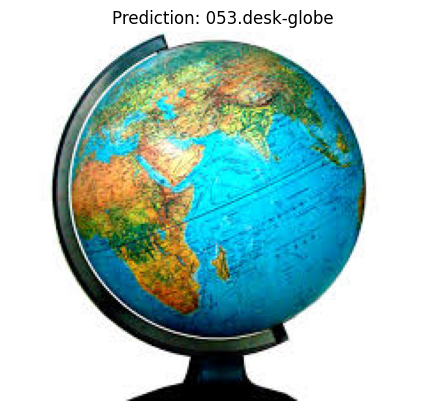

In [45]:
#Mini Google Lense
from PIL import Image
import matplotlib.pyplot as plt

def predict_image(img_path):
    img = Image.open(img_path).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    img_tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        _, predicted = torch.max(outputs, 1)

    class_name = full_dataset.classes[predicted.item()]

    plt.imshow(img)
    plt.title(f"Prediction: {class_name}")
    plt.axis("off")
    plt.show()


predict_image("globe.jpeg")